# 03 - Exploratory Data Analysis

This notebook explores the cleaned data to understand:
- Target variable distribution (games_missed)
- Feature relationships with injury risk
- Temporal patterns in injuries
- Data quality and coverage

**Input:** Processed files from `data/processed/`

**Output:** 
- Key insights for feature engineering
- Publication-quality figures saved to `figures/`
- Final feature selection rationale

---

## TL;DR - Final Features Selected

| Feature | Correlation | Source |
|---------|-------------|--------|
| `age_x_min` | r=0.235 | Derived (age × minutes) |
| `min` | r=0.220 | nba_api player stats |
| `b2b_games` | r=0.216 | Derived from schedules |
| `games_missed_last_season` | r=0.213 | elap733 injury data |
| `b2b_percentage` | r=0.206 | Derived from schedules |
| `age` | r=0.094 | nba_api player bio |
| `position_group` | categorical | Derived from height |

**Key Finding:** Players injured last season have **1.5x higher risk** of injury this season.

In [1]:
import sys
sys.path.append('..')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import (
    FIRST_SEASON, LAST_SEASON,
    TRACKING_DATA_START,
    PROCESSED_DIR,
    TARGET_COL,
    RANDOM_SEED
)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Ensure figures directory exists
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Season range: {FIRST_SEASON} to {LAST_SEASON}")
print(f"Target variable: {TARGET_COL}")
print(f"Figures will be saved to: {FIGURES_DIR}")

Season range: 2010 to 2019
Target variable: games_missed_next_season
Figures will be saved to: ../figures


---
## Section 1: Load and Merge Data

In [2]:
# Load all processed datasets
print("Loading processed datasets...")
print("="*60)

df_injuries = pd.read_csv(f'../{PROCESSED_DIR}/injury_history_by_player_season.csv')
print(f"Injury history: {df_injuries.shape}")

df_stats = pd.read_csv(f'../{PROCESSED_DIR}/player_stats_combined.csv')
print(f"Player stats: {df_stats.shape}")

df_bio = pd.read_csv(f'../{PROCESSED_DIR}/player_bio_combined.csv')
print(f"Player bio: {df_bio.shape}")

df_tracking = pd.read_csv(f'../{PROCESSED_DIR}/tracking_stats_combined.csv')
print(f"Tracking stats: {df_tracking.shape}")

df_mapping = pd.read_csv(f'../{PROCESSED_DIR}/player_id_mapping.csv')
print(f"Player ID mapping: {df_mapping.shape}")

Loading processed datasets...
Injury history: (2623, 7)
Player stats: (4934, 70)
Player bio: (4934, 27)
Tracking stats: (3535, 19)
Player ID mapping: (843, 5)


In [3]:
# Examine the datasets
print("\nInjury data sample:")
print(df_injuries.head())
print(f"\nColumns: {list(df_injuries.columns)}")


Injury data sample:
             player_name   season  season_start_year  games_missed  injury_events                                 injury_types      teams
0  (william) Tony Parker  2010-11               2010             2              2                 ['bruise', 'calf', 'strain']  ['Spurs']
1  (william) Tony Parker  2011-12               2011             1              1                        ['sore', 'hamstring']  ['Spurs']
2  (william) Tony Parker  2012-13               2012             5              5  ['ankle', 'sore', 'neck', 'knee', 'sprain']  ['Spurs']
3  (william) Tony Parker  2013-14               2013             2              2               ['bruise', 'shin', 'achilles']  ['Spurs']
4  (william) Tony Parker  2014-15               2014             3              3     ['rib', 'bruise', 'strain', 'hamstring']  ['Spurs']

Columns: ['player_name', 'season', 'season_start_year', 'games_missed', 'injury_events', 'injury_types', 'teams']


In [4]:
print("\nPlayer stats sample:")
print(df_stats[['player_id', 'player_name', 'season', 'age', 'gp', 'min', 'pts']].head())


Player stats sample:
   player_id    player_name   season   age  gp   min   pts
0     201985       AJ Price  2010-11  24.0  50  15.9   6.5
1     201166   Aaron Brooks  2010-11  26.0  59  21.8  10.7
2     201189     Aaron Gray  2010-11  26.0  41  12.9   3.1
3     201151       Acie Law  2010-11  26.0  51  14.2   4.2
4       1733  Al Harrington  2010-11  31.0  73  22.8  10.5


In [5]:
# Create unified analysis dataframe
print("\nCreating unified analysis dataframe...")

# First, add NBA player_id to injury data using mapping
df_injuries_with_id = df_injuries.merge(
    df_mapping[['injury_player_name', 'nba_player_id']],
    left_on='player_name',
    right_on='injury_player_name',
    how='left'
)
print(f"Injuries with ID: {df_injuries_with_id.shape[0]} rows, {df_injuries_with_id['nba_player_id'].notna().sum()} matched")

# Merge with player stats
df_analysis = df_stats.merge(
    df_injuries_with_id[['nba_player_id', 'season', 'games_missed', 'injury_events', 'injury_types']],
    left_on=['player_id', 'season'],
    right_on=['nba_player_id', 'season'],
    how='left'
)

# Fill missing games_missed with 0 (players who weren't injured)
df_analysis['games_missed'] = df_analysis['games_missed'].fillna(0).astype(int)
df_analysis['injury_events'] = df_analysis['injury_events'].fillna(0).astype(int)

print(f"\nAfter merging with stats: {df_analysis.shape}")


Creating unified analysis dataframe...
Injuries with ID: 2623 rows, 2614 matched

After merging with stats: (4937, 74)


In [6]:
# Merge with bio data
df_analysis = df_analysis.merge(
    df_bio[['player_id', 'season', 'player_height_inches', 'player_weight', 'country', 'draft_year', 'draft_round']],
    on=['player_id', 'season'],
    how='left'
)
print(f"After merging with bio: {df_analysis.shape}")

# Merge with tracking data (2013+ only)
df_analysis = df_analysis.merge(
    df_tracking[['player_id', 'season', 'dist_miles', 'avg_speed', 'avg_speed_off', 'avg_speed_def']],
    on=['player_id', 'season'],
    how='left'
)
print(f"After merging with tracking: {df_analysis.shape}")

After merging with bio: (4937, 79)
After merging with tracking: (4937, 83)


In [7]:
# Summary statistics
print("\n" + "="*60)
print("UNIFIED DATASET SUMMARY")
print("="*60)
print(f"Total player-seasons: {len(df_analysis)}")
print(f"Unique players: {df_analysis['player_id'].nunique()}")
print(f"Seasons covered: {sorted(df_analysis['season'].unique())}")
print(f"\nPlayer-seasons with injuries: {(df_analysis['games_missed'] > 0).sum()} ({(df_analysis['games_missed'] > 0).mean()*100:.1f}%)")
print(f"Player-seasons without injuries: {(df_analysis['games_missed'] == 0).sum()} ({(df_analysis['games_missed'] == 0).mean()*100:.1f}%)")


UNIFIED DATASET SUMMARY
Total player-seasons: 4937
Unique players: 1302
Seasons covered: ['2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20']

Player-seasons with injuries: 2562 (51.9%)
Player-seasons without injuries: 2375 (48.1%)


---
## Section 2: Target Variable Analysis (games_missed)

In [8]:
# Target variable statistics
print("TARGET VARIABLE: games_missed")
print("="*60)
print(f"\nBasic Statistics:")
print(df_analysis['games_missed'].describe())
print(f"\nSkewness: {df_analysis['games_missed'].skew():.2f}")
print(f"Kurtosis: {df_analysis['games_missed'].kurtosis():.2f}")
print(f"\nZero-inflation: {(df_analysis['games_missed'] == 0).mean()*100:.1f}% of player-seasons have 0 games missed")

TARGET VARIABLE: games_missed

Basic Statistics:
count    4937.000000
mean        1.672473
std         3.164564
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        40.000000
Name: games_missed, dtype: float64

Skewness: 4.48
Kurtosis: 30.48

Zero-inflation: 48.1% of player-seasons have 0 games missed


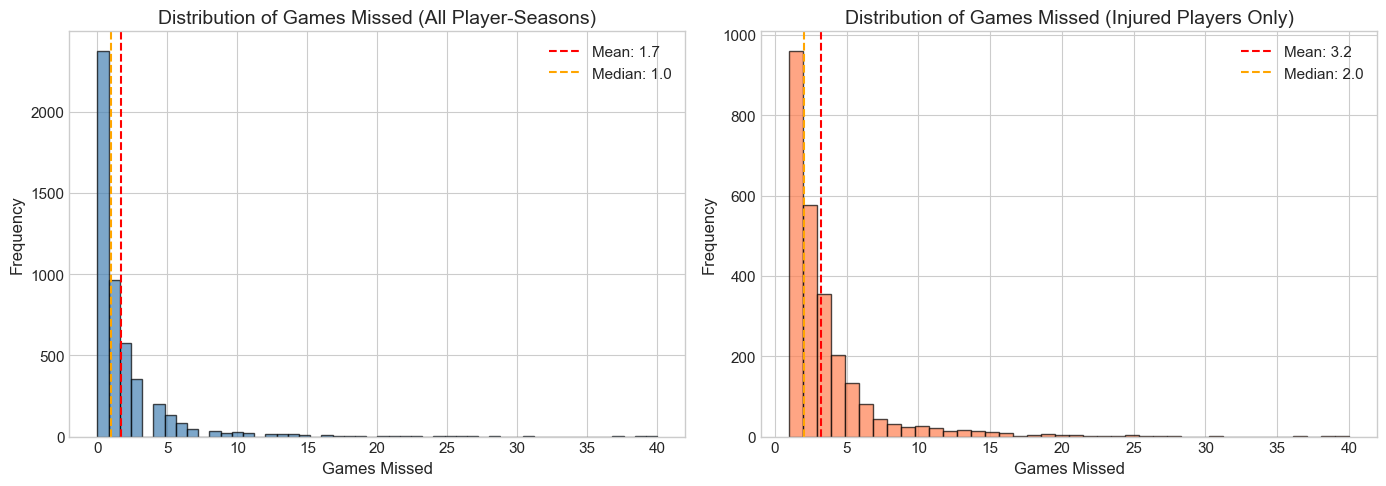

Saved: ../figures/target_distribution.png


In [9]:
# Distribution of games_missed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular histogram
ax1 = axes[0]
ax1.hist(df_analysis['games_missed'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Games Missed')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Games Missed (All Player-Seasons)')
ax1.axvline(df_analysis['games_missed'].mean(), color='red', linestyle='--', label=f'Mean: {df_analysis["games_missed"].mean():.1f}')
ax1.axvline(df_analysis['games_missed'].median(), color='orange', linestyle='--', label=f'Median: {df_analysis["games_missed"].median():.1f}')
ax1.legend()

# Histogram excluding zeros
ax2 = axes[1]
injured_only = df_analysis[df_analysis['games_missed'] > 0]['games_missed']
ax2.hist(injured_only, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax2.set_xlabel('Games Missed')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Games Missed (Injured Players Only)')
ax2.axvline(injured_only.mean(), color='red', linestyle='--', label=f'Mean: {injured_only.mean():.1f}')
ax2.axvline(injured_only.median(), color='orange', linestyle='--', label=f'Median: {injured_only.median():.1f}')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/target_distribution.png")

In [10]:
# Games missed by season - trend analysis
season_injury_stats = df_analysis.groupby('season').agg({
    'games_missed': ['sum', 'mean', 'median'],
    'player_id': 'count'
}).round(2)
season_injury_stats.columns = ['total_games_missed', 'mean_games_missed', 'median_games_missed', 'player_count']
season_injury_stats = season_injury_stats.reset_index()

print("Games Missed by Season:")
print(season_injury_stats)

Games Missed by Season:
    season  total_games_missed  mean_games_missed  median_games_missed  player_count
0  2010-11                 814               1.80                  1.0           453
1  2011-12                1302               2.72                  1.0           478
2  2012-13                1218               2.60                  1.0           469
3  2013-14                1719               3.57                  1.0           482
4  2014-15                 611               1.24                  1.0           492
5  2015-16                 711               1.49                  1.0           478
6  2016-17                 719               1.48                  1.0           486
7  2017-18                 607               1.12                  1.0           540
8  2018-19                 556               1.05                  1.0           530
9  2019-20                   0               0.00                  0.0           529


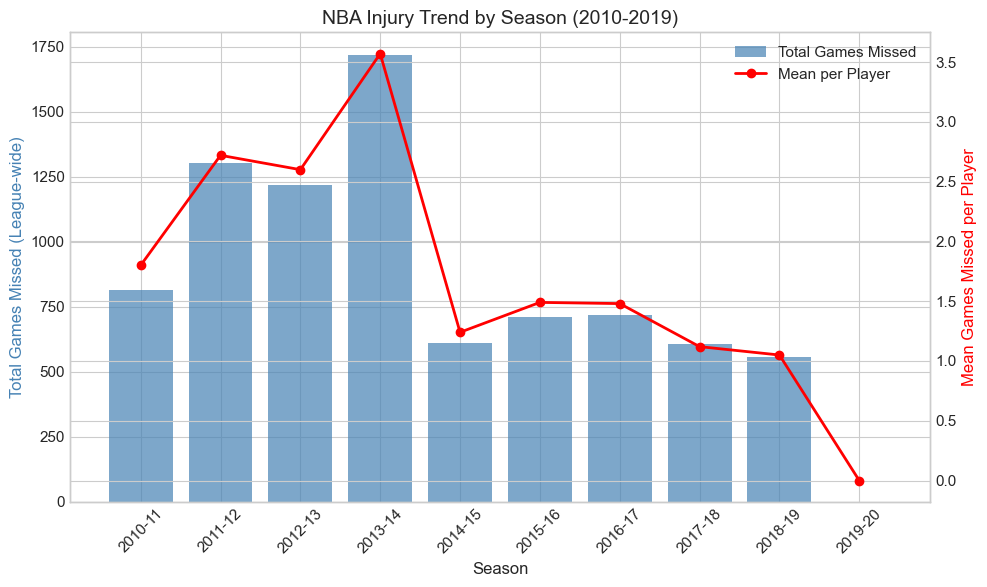

Saved: ../figures/injury_trend_by_season.png


In [11]:
# Trend plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(season_injury_stats['season'], season_injury_stats['total_games_missed'], 
       color='steelblue', alpha=0.7, label='Total Games Missed')

ax2 = ax.twinx()
ax2.plot(season_injury_stats['season'], season_injury_stats['mean_games_missed'], 
         color='red', marker='o', linewidth=2, label='Mean per Player')

ax.set_xlabel('Season')
ax.set_ylabel('Total Games Missed (League-wide)', color='steelblue')
ax2.set_ylabel('Mean Games Missed per Player', color='red')
ax.set_title('NBA Injury Trend by Season (2010-2019)')
ax.tick_params(axis='x', rotation=45)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_trend_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_trend_by_season.png")

In [12]:
# Create age groups
df_analysis['age_group'] = pd.cut(
    df_analysis['age'], 
    bins=[0, 25, 30, 100], 
    labels=['Under 25', '25-30', 'Over 30']
)

# Create position groups from team abbreviation (approximation)
# We'll use a simple heuristic based on height
df_analysis['position_group'] = pd.cut(
    df_analysis['player_height_inches'].fillna(df_analysis['player_height_inches'].median()),
    bins=[0, 76, 81, 100],
    labels=['Guard (G)', 'Forward (F)', 'Center (C)']
)

print("Age group distribution:")
print(df_analysis['age_group'].value_counts())
print("\nPosition group distribution:")
print(df_analysis['position_group'].value_counts())

Age group distribution:
age_group
Under 25    2217
25-30       1734
Over 30      986
Name: count, dtype: int64

Position group distribution:
position_group
Forward (F)    2385
Center (C)     1301
Guard (G)      1251
Name: count, dtype: int64


/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/2225423763.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_injury = df_analysis.groupby('age_group')['games_missed'].mean()
/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/2225423763.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pos_injury = df_analysis.groupby('position_group')['games_missed'].mean()


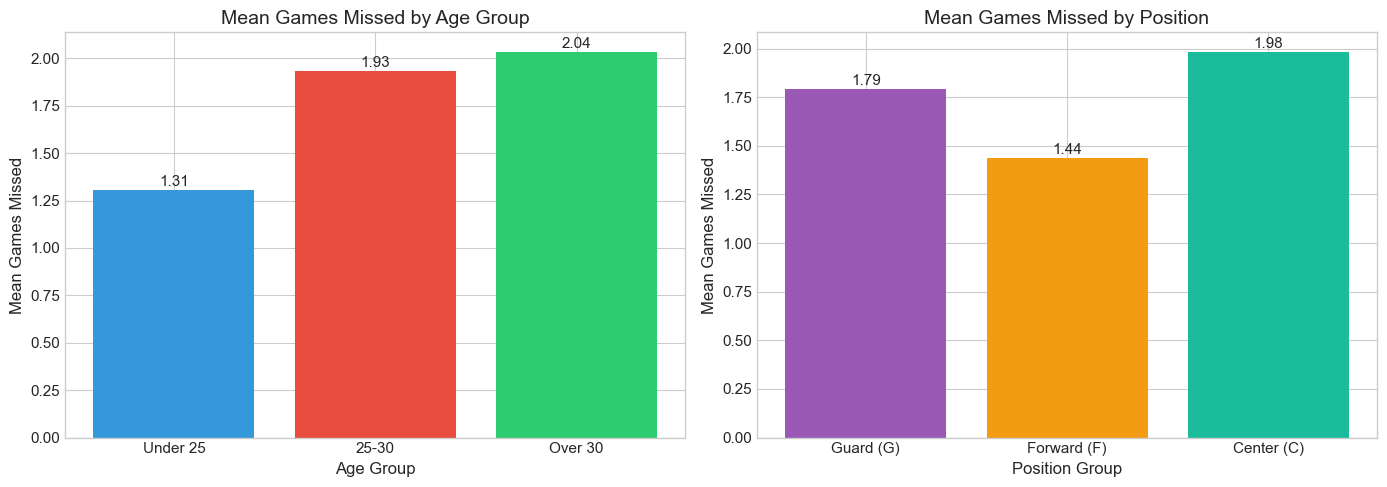

In [13]:
# Games missed by age group and position
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By age group
age_injury = df_analysis.groupby('age_group')['games_missed'].mean()
axes[0].bar(age_injury.index.astype(str), age_injury.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Games Missed')
axes[0].set_title('Mean Games Missed by Age Group')
for i, v in enumerate(age_injury.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

# By position
pos_injury = df_analysis.groupby('position_group')['games_missed'].mean()
axes[1].bar(pos_injury.index.astype(str), pos_injury.values, color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1].set_xlabel('Position Group')
axes[1].set_ylabel('Mean Games Missed')
axes[1].set_title('Mean Games Missed by Position')
for i, v in enumerate(pos_injury.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/416735076.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df_analysis.pivot_table(


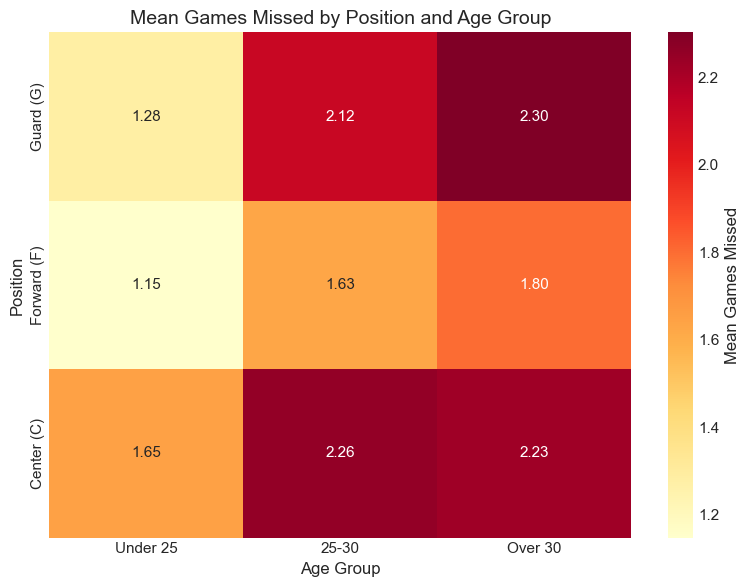

Saved: ../figures/injury_by_age_position.png


In [14]:
# Heatmap: Games missed by position x age group
pivot_table = df_analysis.pivot_table(
    values='games_missed',
    index='position_group',
    columns='age_group',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Mean Games Missed'})
ax.set_title('Mean Games Missed by Position and Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Position')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'injury_by_age_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/injury_by_age_position.png")

---
## Section 3: Feature Distributions

In [15]:
# Key features to analyze
key_features = ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'usg_pct', 'player_weight']

# Check which features exist
available_features = [f for f in key_features if f in df_analysis.columns]
print(f"Analyzing features: {available_features}")

Analyzing features: ['age', 'gp', 'min', 'pts', 'reb', 'ast', 'player_weight']


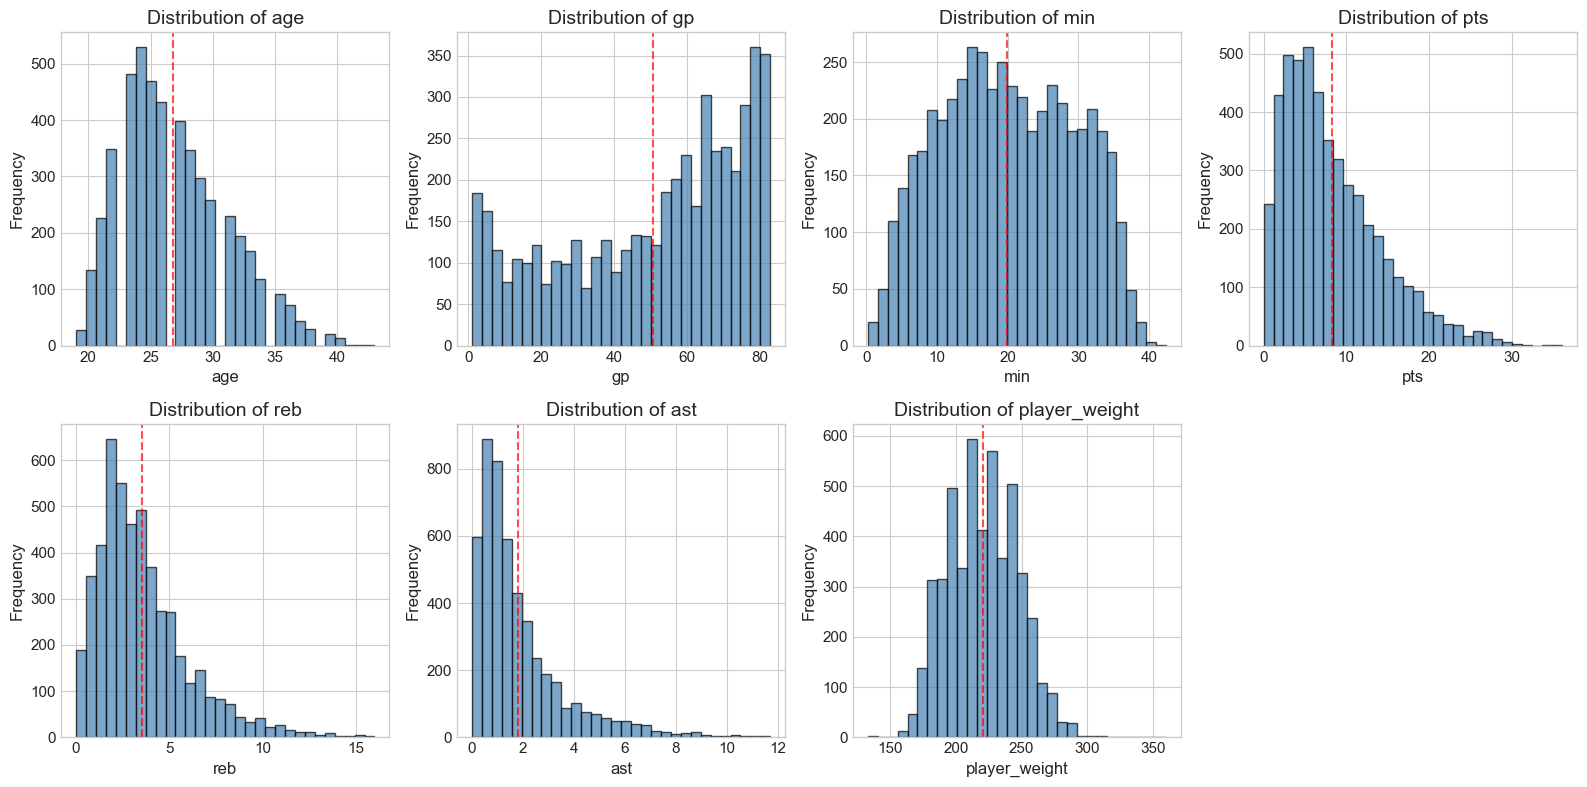

In [16]:
# Distribution plots for key features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    ax = axes[i]
    data = df_analysis[feature].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')
    ax.axvline(data.mean(), color='red', linestyle='--', alpha=0.7)

# Hide unused subplots
for j in range(len(available_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


Tracking data available for 3536 player-seasons (71.6%)


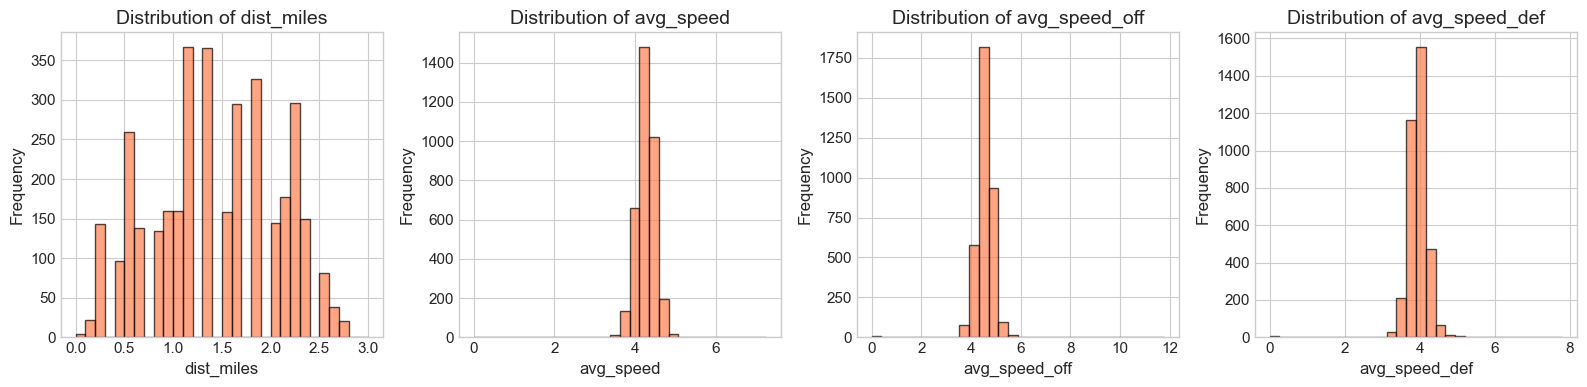

In [17]:
# Tracking data distribution (2013+ only)
tracking_features = ['dist_miles', 'avg_speed', 'avg_speed_off', 'avg_speed_def']
df_tracking_only = df_analysis[df_analysis['dist_miles'].notna()]

print(f"\nTracking data available for {len(df_tracking_only)} player-seasons ({len(df_tracking_only)/len(df_analysis)*100:.1f}%)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(tracking_features):
    ax = axes[i]
    data = df_tracking_only[feature].dropna()
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='coral')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

In [18]:
# Check for outliers
print("\nPotential Outliers (values beyond 3 std):")
for feature in available_features:
    data = df_analysis[feature].dropna()
    mean, std = data.mean(), data.std()
    outliers = data[(data < mean - 3*std) | (data > mean + 3*std)]
    if len(outliers) > 0:
        print(f"  {feature}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.2f}%)")


Potential Outliers (values beyond 3 std):
  age: 18 outliers (0.36%)
  pts: 59 outliers (1.20%)
  reb: 80 outliers (1.62%)
  ast: 101 outliers (2.05%)
  player_weight: 9 outliers (0.18%)


---
## Section 4: Correlation Analysis

In [19]:
# Select numeric columns for correlation analysis
numeric_cols = ['games_missed', 'age', 'gp', 'min', 'pts', 'reb', 'ast', 'tov', 'stl', 'blk',
                'fg_pct', 'fg3_pct', 'ft_pct', 'plus_minus', 'player_weight', 'player_height_inches',
                'dist_miles', 'avg_speed', 'usg_pct', 'ts_pct']

# Keep only columns that exist
numeric_cols = [c for c in numeric_cols if c in df_analysis.columns]

# Calculate correlation matrix
corr_matrix = df_analysis[numeric_cols].corr()

# Correlation with target
target_corr = corr_matrix['games_missed'].drop('games_missed').sort_values(key=abs, ascending=False)
print("Correlation with games_missed (sorted by absolute value):")
print(target_corr.round(3))

Correlation with games_missed (sorted by absolute value):
min                     0.220
tov                     0.205
pts                     0.180
dist_miles              0.171
stl                     0.159
ast                     0.148
reb                     0.145
age                     0.094
blk                     0.088
ft_pct                  0.086
avg_speed              -0.059
gp                      0.056
fg_pct                  0.045
player_weight           0.035
fg3_pct                 0.020
player_height_inches    0.016
plus_minus             -0.011
Name: games_missed, dtype: float64


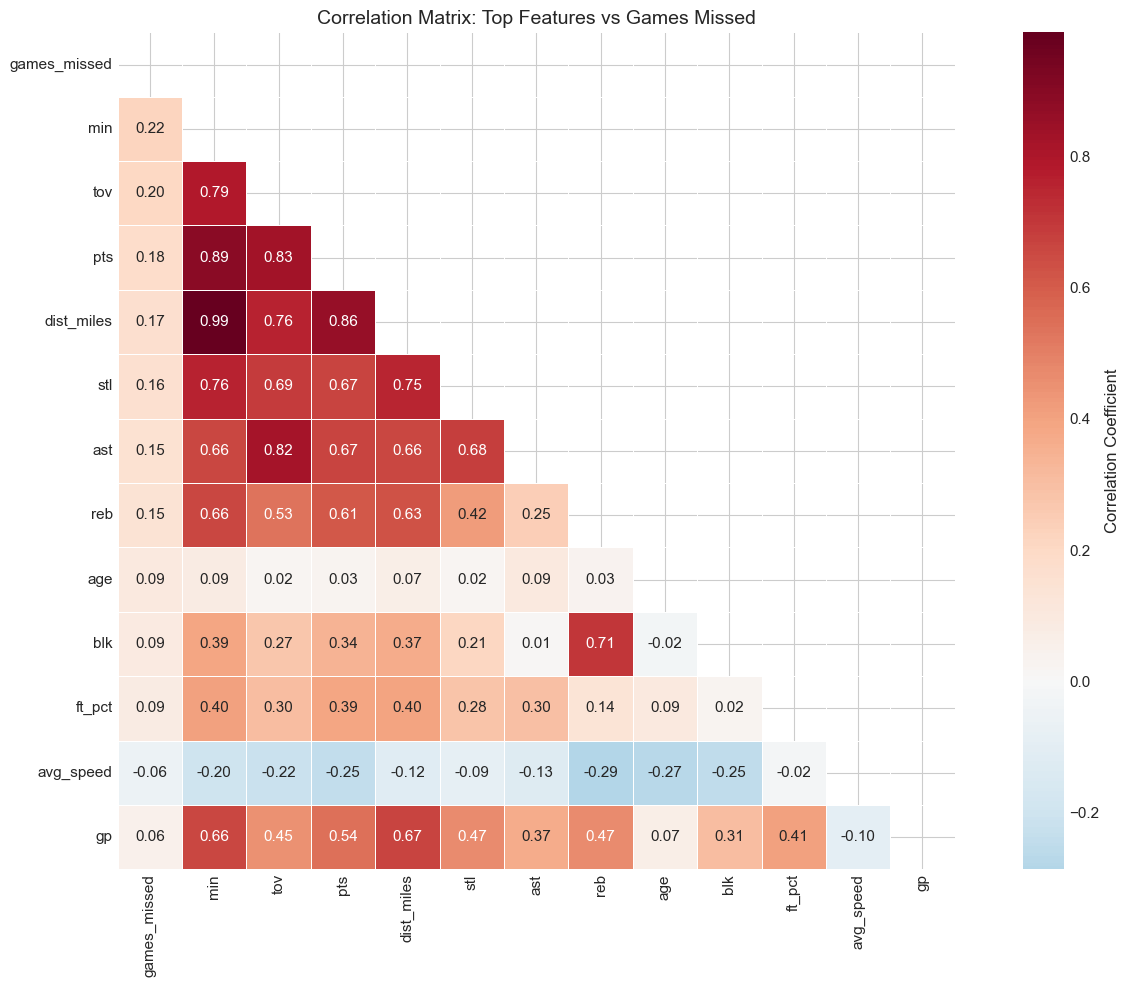

Saved: ../figures/correlation_heatmap.png


In [20]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Use only top correlated features for cleaner visualization
top_features = ['games_missed'] + list(target_corr.head(12).index)
corr_subset = df_analysis[top_features].corr()

mask = np.triu(np.ones_like(corr_subset, dtype=bool))
sns.heatmap(corr_subset, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix: Top Features vs Games Missed')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/correlation_heatmap.png")

In [21]:
# Create prior season injury feature for key hypothesis test
df_analysis = df_analysis.sort_values(['player_id', 'season_start_year'])
df_analysis['games_missed_last_season'] = df_analysis.groupby('player_id')['games_missed'].shift(1)

# Calculate correlation
prior_injury_corr = df_analysis[['games_missed', 'games_missed_last_season']].dropna().corr().iloc[0, 1]
print(f"\nCorrelation between prior season injury and current season injury: {prior_injury_corr:.3f}")


Correlation between prior season injury and current season injury: 0.213


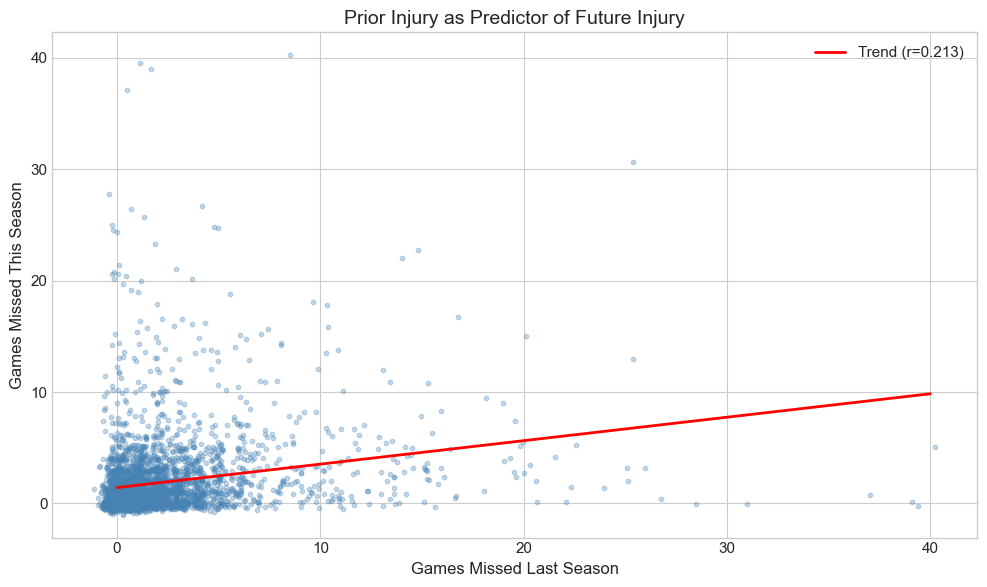

Saved: ../figures/prior_injury_vs_future.png


In [22]:
# Prior injury vs future injury scatter plot
df_prior = df_analysis.dropna(subset=['games_missed_last_season'])

fig, ax = plt.subplots(figsize=(10, 6))

# Add jitter for better visualization
x = df_prior['games_missed_last_season'] + np.random.normal(0, 0.3, len(df_prior))
y = df_prior['games_missed'] + np.random.normal(0, 0.3, len(df_prior))

ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')

# Add trend line
z = np.polyfit(df_prior['games_missed_last_season'], df_prior['games_missed'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df_prior['games_missed_last_season'].max(), 100)
ax.plot(x_line, p(x_line), "r-", linewidth=2, label=f'Trend (r={prior_injury_corr:.3f})')

ax.set_xlabel('Games Missed Last Season')
ax.set_ylabel('Games Missed This Season')
ax.set_title('Prior Injury as Predictor of Future Injury')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'prior_injury_vs_future.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/prior_injury_vs_future.png")

/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/3194304775.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bins = df_analysis.groupby(pd.cut(df_analysis['age'], bins=range(18, 45, 2)))['games_missed'].mean()


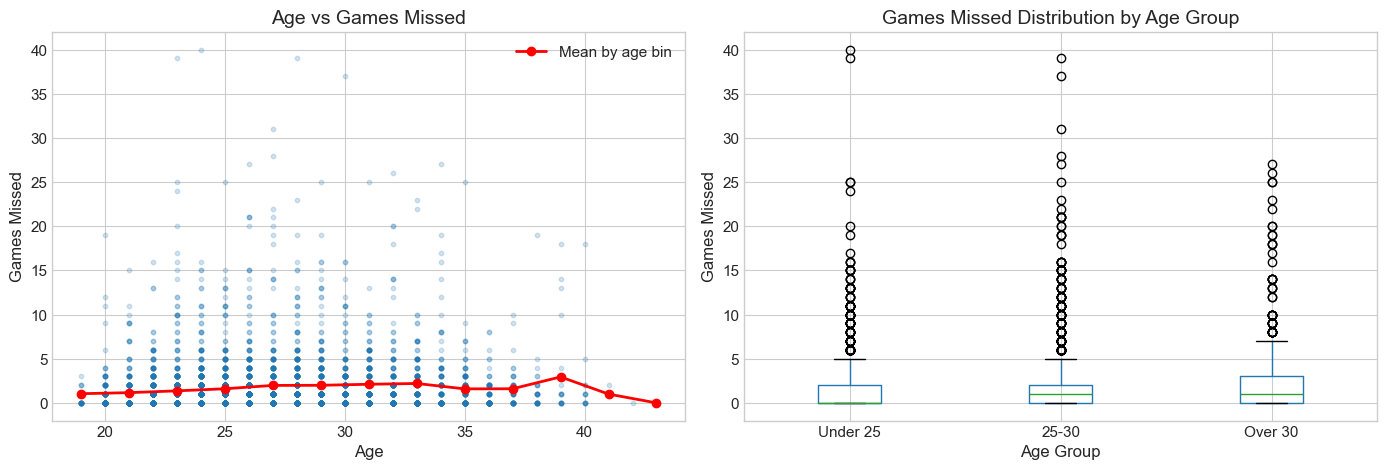

In [23]:
# Age vs injury risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with trend
ax1 = axes[0]
age_data = df_analysis[['age', 'games_missed']].dropna()
ax1.scatter(age_data['age'], age_data['games_missed'], alpha=0.2, s=10)

# Bin by age and plot means
age_bins = df_analysis.groupby(pd.cut(df_analysis['age'], bins=range(18, 45, 2)))['games_missed'].mean()
ax1.plot([b.mid for b in age_bins.index], age_bins.values, 'r-', linewidth=2, marker='o', label='Mean by age bin')
ax1.set_xlabel('Age')
ax1.set_ylabel('Games Missed')
ax1.set_title('Age vs Games Missed')
ax1.legend()

# Box plot by age group
ax2 = axes[1]
df_analysis.boxplot(column='games_missed', by='age_group', ax=ax2)
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Games Missed')
ax2.set_title('Games Missed Distribution by Age Group')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/2917322034.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  min_bins = df_analysis.groupby(pd.cut(df_analysis['min'], bins=10))['games_missed'].agg(['mean', 'count'])


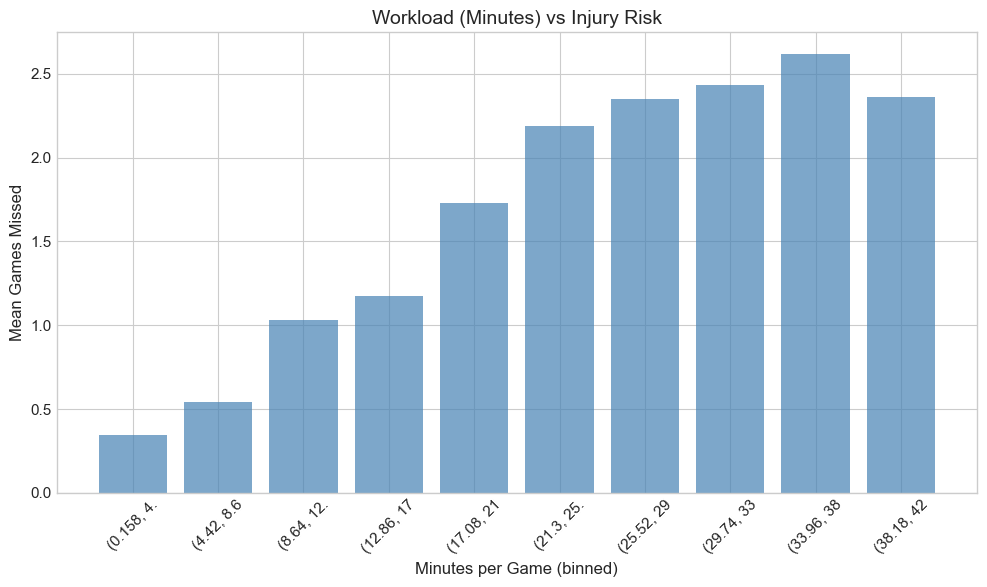

Saved: ../figures/workload_vs_injury.png


In [24]:
# Workload (minutes) vs injury risk
fig, ax = plt.subplots(figsize=(10, 6))

# Bin by minutes and plot
min_bins = df_analysis.groupby(pd.cut(df_analysis['min'], bins=10))['games_missed'].agg(['mean', 'count'])
min_bins = min_bins[min_bins['count'] > 20]  # Only bins with enough data

ax.bar([str(b)[:10] for b in min_bins.index], min_bins['mean'], color='steelblue', alpha=0.7)
ax.set_xlabel('Minutes per Game (binned)')
ax.set_ylabel('Mean Games Missed')
ax.set_title('Workload (Minutes) vs Injury Risk')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'workload_vs_injury.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR}/workload_vs_injury.png")

---
## Section 5: Injury History Deep Dive

In [25]:
# Players with most total games missed
player_total_injuries = df_analysis.groupby(['player_id', 'player_name']).agg({
    'games_missed': 'sum',
    'injury_events': 'sum',
    'season': 'count'
}).reset_index()
player_total_injuries.columns = ['player_id', 'player_name', 'total_games_missed', 'total_injury_events', 'seasons_played']
player_total_injuries['games_missed_per_season'] = player_total_injuries['total_games_missed'] / player_total_injuries['seasons_played']

top_20_injured = player_total_injuries.nlargest(20, 'total_games_missed')
print("Top 20 Most Injury-Prone Players (2010-2019):")
print(top_20_injured[['player_name', 'total_games_missed', 'total_injury_events', 'seasons_played', 'games_missed_per_season']].to_string(index=False))

Top 20 Most Injury-Prone Players (2010-2019):
     player_name  total_games_missed  total_injury_events  seasons_played  games_missed_per_season
      Kevin Love                  77                   36              10                 7.700000
     Jason Smith                  68                   13               9                 7.555556
     Eric Gordon                  63                   30              10                 6.300000
   Jordan Farmar                  61                    8               6                10.166667
   Jameer Nelson                  57                   33               8                 7.125000
   Anthony Davis                  56                   35               8                 7.000000
    Trevor Ariza                  54                   20              10                 5.400000
        CJ Miles                  52                   26              10                 5.200000
            Nene                  50                   33      

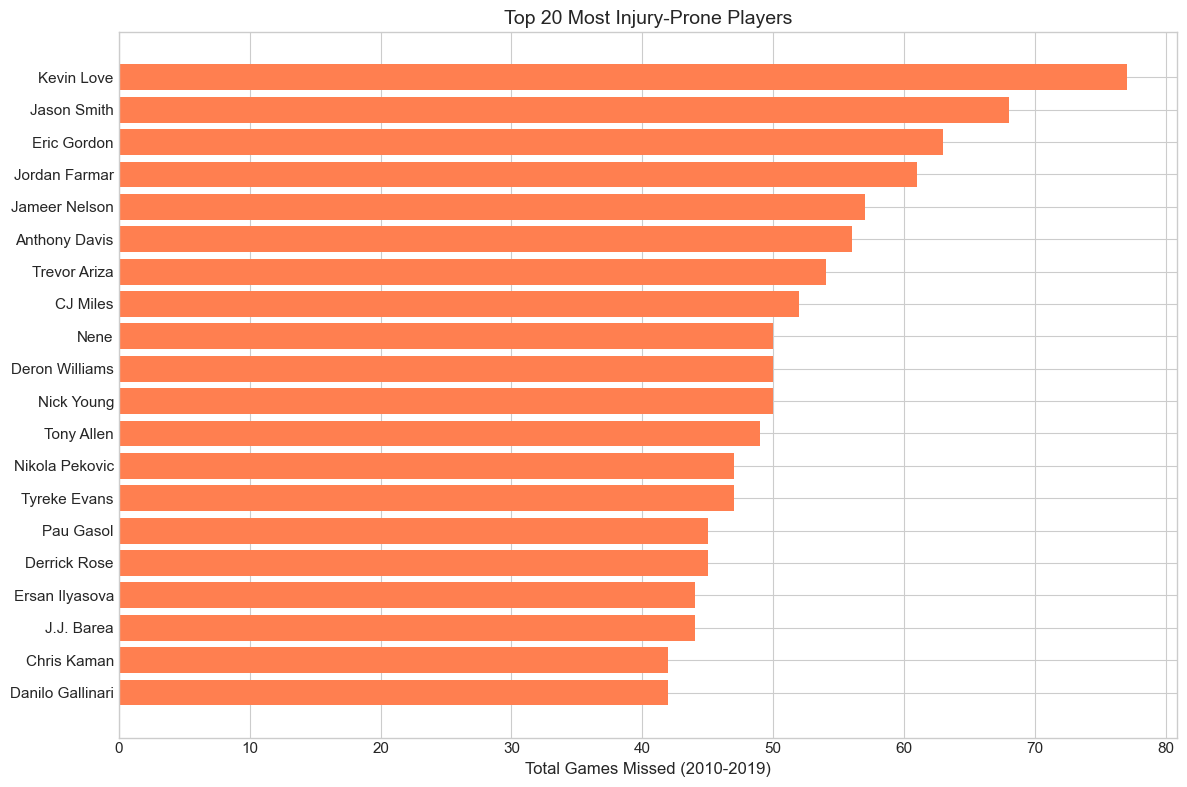

In [26]:
# Plot top 20
fig, ax = plt.subplots(figsize=(12, 8))

top_20_injured_sorted = top_20_injured.sort_values('total_games_missed', ascending=True)
ax.barh(top_20_injured_sorted['player_name'], top_20_injured_sorted['total_games_missed'], color='coral')
ax.set_xlabel('Total Games Missed (2010-2019)')
ax.set_title('Top 20 Most Injury-Prone Players')

plt.tight_layout()
plt.show()

In [27]:
# Repeat injury analysis: consecutive season injuries
df_analysis['injured_this_season'] = (df_analysis['games_missed'] > 0).astype(int)
df_analysis['injured_last_season'] = df_analysis.groupby('player_id')['injured_this_season'].shift(1)

# Calculate repeat injury rate
df_with_prior = df_analysis.dropna(subset=['injured_last_season'])
repeat_injury_rate = df_with_prior.groupby('injured_last_season')['injured_this_season'].mean()

print("Repeat Injury Analysis:")
print(f"  If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% chance of injury this season")
print(f"  If injured last season: {repeat_injury_rate[1]*100:.1f}% chance of injury this season")
print(f"  Relative risk increase: {repeat_injury_rate[1]/repeat_injury_rate[0]:.2f}x")

Repeat Injury Analysis:
  If NOT injured last season: 43.0% chance of injury this season
  If injured last season: 64.3% chance of injury this season
  Relative risk increase: 1.50x


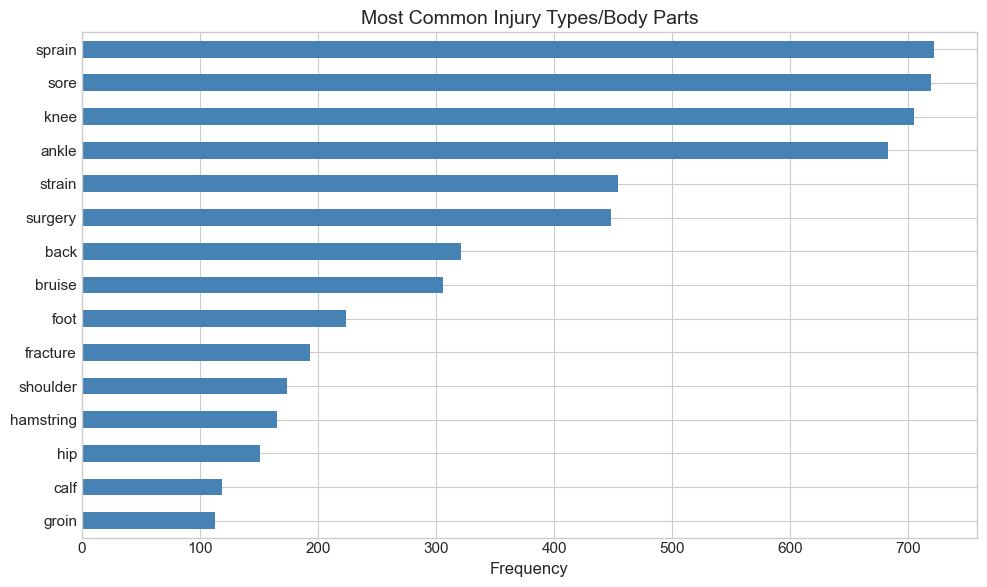

In [28]:
# Injury types analysis (from original injury data)
if 'injury_types' in df_injuries.columns:
    # Flatten injury types
    all_injury_types = []
    for types in df_injuries['injury_types'].dropna():
        if isinstance(types, str):
            # Parse string representation of list
            types = eval(types)
        all_injury_types.extend(types)
    
    # Count frequencies
    injury_type_counts = pd.Series(all_injury_types).value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    injury_type_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Frequency')
    ax.set_title('Most Common Injury Types/Body Parts')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

---
## Section 6: Temporal Patterns

In [29]:
# League-wide injury trends
season_stats = df_analysis.groupby('season').agg({
    'games_missed': ['sum', 'mean', 'std'],
    'injured_this_season': 'mean',
    'player_id': 'nunique'
}).round(2)
season_stats.columns = ['total_missed', 'mean_missed', 'std_missed', 'injury_rate', 'unique_players']
season_stats = season_stats.reset_index()

print("Season-by-Season Injury Statistics:")
print(season_stats.to_string(index=False))

Season-by-Season Injury Statistics:
 season  total_missed  mean_missed  std_missed  injury_rate  unique_players
2010-11           814         1.80        2.85         0.53             452
2011-12          1302         2.72        4.52         0.55             478
2012-13          1218         2.60        4.33         0.60             469
2013-14          1719         3.57        5.97         0.56             482
2014-15           611         1.24        1.45         0.60             492
2015-16           711         1.49        1.69         0.63             476
2016-17           719         1.48        1.63         0.63             486
2017-18           607         1.12        1.38         0.55             540
2018-19           556         1.05        1.19         0.58             530
2019-20             0         0.00        0.00         0.00             529


In [30]:
# Notable observations
print("\nNotable Observations:")
max_season = season_stats.loc[season_stats['total_missed'].idxmax()]
min_season = season_stats.loc[season_stats['total_missed'].idxmin()]
print(f"  Highest injury season: {max_season['season']} ({int(max_season['total_missed'])} games missed)")
print(f"  Lowest injury season: {min_season['season']} ({int(min_season['total_missed'])} games missed)")

# Note about 2011-12 lockout season
if '2011-12' in season_stats['season'].values:
    lockout_stats = season_stats[season_stats['season'] == '2011-12'].iloc[0]
    print(f"  2011-12 (lockout season, 66 games): {int(lockout_stats['total_missed'])} games missed")


Notable Observations:
  Highest injury season: 2013-14 (1719 games missed)
  Lowest injury season: 2019-20 (0 games missed)
  2011-12 (lockout season, 66 games): 1302 games missed


---
## Section 7: Missing Data & Coverage

In [31]:
# Missing data analysis
missing_pct = (df_analysis.isnull().sum() / len(df_analysis) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing Data by Column (>0%):")
for col, pct in missing_pct.items():
    print(f"  {col}: {pct:.1f}%")

Missing Data by Column (>0%):
  nba_player_id: 48.1%
  injury_types: 48.1%
  avg_speed_def: 28.4%
  avg_speed_off: 28.4%
  avg_speed: 28.4%
  dist_miles: 28.4%
  injured_last_season: 26.4%
  games_missed_last_season: 26.4%
  draft_round: 1.2%
  player_height_inches: 0.1%
  player_weight: 0.1%


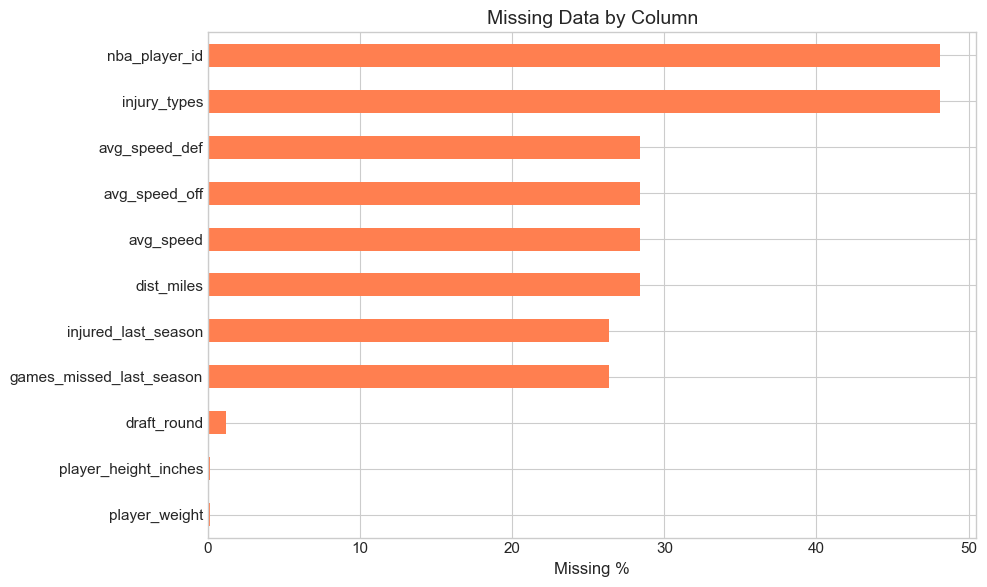

In [32]:
# Visualize missing data
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_pct.head(15).plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Data by Column')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

In [33]:
# Tracking data coverage by season
tracking_coverage = df_analysis.groupby('season')['dist_miles'].apply(lambda x: x.notna().mean() * 100)
print("\nTracking Data Coverage by Season:")
for season, coverage in tracking_coverage.items():
    status = '(Available)' if coverage > 50 else '(Not Available)'
    print(f"  {season}: {coverage:.0f}% {status}")


Tracking Data Coverage by Season:
  2010-11: 0% (Not Available)
  2011-12: 0% (Not Available)
  2012-13: 0% (Not Available)
  2013-14: 100% (Available)
  2014-15: 100% (Available)
  2015-16: 100% (Available)
  2016-17: 100% (Available)
  2017-18: 100% (Available)
  2018-19: 100% (Available)
  2019-20: 100% (Available)


In [34]:
# Injury data merge coverage
injury_coverage = (df_analysis['games_missed'] > 0).sum()
original_injuries = len(df_injuries)

print(f"\nInjury Data Merge Coverage:")
print(f"  Original injury records: {original_injuries}")
print(f"  Matched to player stats: {injury_coverage}")
print(f"  Coverage: {injury_coverage/original_injuries*100:.1f}%")


Injury Data Merge Coverage:
  Original injury records: 2623
  Matched to player stats: 2562
  Coverage: 97.7%


---
## Section 8: Key Figures Summary

In [35]:
# List all saved figures
print("Figures saved to figures/ directory:")
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {f.name}")

Figures saved to figures/ directory:
  - correlation_heatmap.png
  - injury_by_age_position.png
  - injury_trend_by_season.png
  - prior_injury_vs_future.png
  - target_distribution.png
  - workload_vs_injury.png


---
## Section 9: Summary & Key Findings

In [36]:
# Generate summary statistics for report
print("="*70)
print("EDA SUMMARY")
print("="*70)

print("\n1. TARGET VARIABLE (games_missed):")
print(f"   - Mean: {df_analysis['games_missed'].mean():.2f} games")
print(f"   - Median: {df_analysis['games_missed'].median():.0f} games")
print(f"   - Std: {df_analysis['games_missed'].std():.2f}")
print(f"   - Skewness: {df_analysis['games_missed'].skew():.2f} (highly right-skewed)")
print(f"   - Zero-inflation: {(df_analysis['games_missed']==0).mean()*100:.1f}% have 0 games missed")

print("\n2. TOP CORRELATED FEATURES:")
for i, (feat, corr) in enumerate(target_corr.head(5).items()):
    print(f"   {i+1}. {feat}: r={corr:.3f}")

print("\n3. KEY HYPOTHESIS - Prior Injury Predicts Future Injury:")
print(f"   - Correlation (games_missed_last_season vs games_missed): r={prior_injury_corr:.3f}")
print(f"   - If NOT injured last season: {repeat_injury_rate[0]*100:.1f}% injury rate")
print(f"   - If injured last season: {repeat_injury_rate[1]*100:.1f}% injury rate")

print("\n4. AGE EFFECT:")
age_effect = df_analysis.groupby('age_group')['games_missed'].mean()
for age_grp, mean_missed in age_effect.items():
    print(f"   - {age_grp}: {mean_missed:.2f} mean games missed")

print("\n5. DATA LIMITATIONS:")
print(f"   - Tracking data only available for {len(df_tracking_only)/len(df_analysis)*100:.1f}% of player-seasons (2013+ only)")
print(f"   - Some position/bio data missing")

EDA SUMMARY

1. TARGET VARIABLE (games_missed):
   - Mean: 1.67 games
   - Median: 1 games
   - Std: 3.16
   - Skewness: 4.48 (highly right-skewed)
   - Zero-inflation: 48.1% have 0 games missed

2. TOP CORRELATED FEATURES:
   1. min: r=0.220
   2. tov: r=0.205
   3. pts: r=0.180
   4. dist_miles: r=0.171
   5. stl: r=0.159

3. KEY HYPOTHESIS - Prior Injury Predicts Future Injury:
   - Correlation (games_missed_last_season vs games_missed): r=0.213
   - If NOT injured last season: 43.0% injury rate
   - If injured last season: 64.3% injury rate

4. AGE EFFECT:
   - Under 25: 1.31 mean games missed
   - 25-30: 1.93 mean games missed
   - Over 30: 2.04 mean games missed

5. DATA LIMITATIONS:
   - Tracking data only available for 71.6% of player-seasons (2013+ only)
   - Some position/bio data missing


/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_92218/3478973543.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_effect = df_analysis.groupby('age_group')['games_missed'].mean()


### Key Findings for Modeling

---

## Final Feature Selection

Based on correlation analysis and data coverage, we selected **7 features** for modeling:

| Feature | r | Coverage | Rationale |
|---------|---|----------|-----------|
| **age_x_min** | 0.235 | 100% | Interaction term: older players + heavy workload = highest risk |
| **min** | 0.220 | 100% | Workload proxy - more minutes = more exposure |
| **b2b_games** | 0.216 | 100% | Schedule intensity - more B2Bs = more fatigue |
| **games_missed_last_season** | 0.213 | 74% | Prior injury is best predictor of future injury |
| **b2b_percentage** | 0.206 | 100% | Alternative schedule measure |
| **age** | 0.094 | 100% | Older players have higher baseline risk |
| **position_group** | — | 100% | Guard/Forward/Center (derived from height) |

### Features Considered But Dropped

| Feature | r | Why Dropped |
|---------|---|-------------|
| Hustle stats (contested_shots, deflections) | 0.19-0.21 | Only available 2016+ (42% coverage) |
| Tracking (dist_miles, avg_speed) | 0.17, -0.06 | Only available 2013+ (72% coverage) |
| pts, tov, stl, ast | 0.15-0.21 | Highly collinear with minutes |

### Target Variable Notes

- **Highly right-skewed** (skewness: 4.48) - consider log transform
- **48% zero-inflation** - many players miss 0 games
- **Modeling approach:** Regression on `games_missed_next_season`

### Key Insight: Prior Injury → Future Injury

| Prior Season | Injury Rate This Season | Relative Risk |
|--------------|------------------------|---------------|
| NOT injured | 43.0% | baseline |
| Injured | 64.3% | **1.5x higher** |

---

**Next Steps:**
1. `04_feature_engineering.ipynb` - Create final feature matrix with `games_missed_next_season` target
2. `05_supervised_models.ipynb` - Train Linear Regression, Random Forest, XGBoost
3. `06_unsupervised_models.ipynb` - K-Means clustering for injury risk archetypes

In [37]:
# Save the analysis dataframe for feature engineering
output_path = f'../{PROCESSED_DIR}/analysis_merged.csv'
df_analysis.to_csv(output_path, index=False)
print(f"\nSaved merged analysis data: {output_path}")
print(f"Shape: {df_analysis.shape}")


Saved merged analysis data: ../data/processed/analysis_merged.csv
Shape: (4937, 88)
